In [4]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

In [22]:
import cma
import numpy as np
from numbers import Real
from transformers import CLIPProcessor, CLIPModel
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
from sentence_transformers import CrossEncoder
import os
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *



DEVICE='cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')

In [6]:
def pad_resize(img):
    img.thumbnail((WIDTH, HEIGHT))
    return img

def spec_img(dir, name, dic):
  # Assume name is of format name.png
  dic[name.split('.')[0]] = pad_resize(Image.open(path.join(dir, name)))

def default_img(name, dic):
  spec_img(PRIMITIVES_DIR, name, dic)

def spec_path(dir, name, dic):
  # Assume name is of format name.png
  dic[name.split('.')[0]] = path.join(dir, name)

def default_path(name, dic):
  spec_path(PRIMITIVES_DIR, name, dic)

def add_synonyms(synonyms, dic):
  for s in synonyms:
    dic[s] = dic[synonyms[s]]

SEGMENT_IMGS = {}

for filename in os.listdir(SEGMENT_DIR):
    full_path = os.path.join(SEGMENT_DIR, filename)
    # Check if filename is dir
    if os.path.isdir(full_path):
        # Create all primitives dict (composed of segments)
        SEGMENT_PRIMITIVES = {}
        for segment_name in os.listdir(full_path):
          if segment_name.lower().endswith(".png"):
              spec_img(full_path, segment_name, SEGMENT_PRIMITIVES)

        # Add segments to all primitives dict
        SEGMENT_IMGS[filename] = SEGMENT_PRIMITIVES

In [7]:
model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(DEVICE)
def CLIP_emb_from_IMG(IMG):
  inputs = processor(images=IMG, return_tensors="pt", padding=True).to(DEVICE)

  with torch.no_grad():
    image_features = model.get_image_features(**inputs)
    image_features = image_features / image_features.norm(dim=1, keepdim=True)

  return image_features

def CLIP_emb_from_TEXT(TEXT):
  inputs = processor(text=TEXT, return_tensors="pt", padding=True).to(DEVICE)

  with torch.no_grad():
    text_features = model.get_text_features(**inputs)
    text_features = text_features / text_features.norm(dim=1, keepdim=True)
  return text_features



In [8]:
def loss(solution):
    solution = np.clip(solution.reshape(-1, predictN), 0.01, 1)
    img = rasterize_shapes(primitives_selected, solution, (WIDTH, HEIGHT))
    img = Image.alpha_composite(
        Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
        img
    ).convert("RGB")

    rasterized_imgs = torch.tensor(np.array(img)).permute(2, 0, 1).to(DEVICE)
    rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) 

    return -torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1).item()

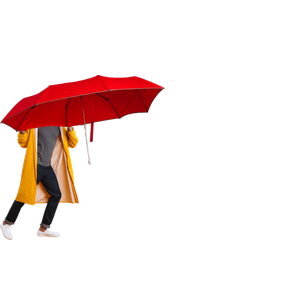

In [88]:
prompt_text = 'the statue of liberty'
prompt_text = 'a person holding an umbrella'
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)
#prompt_embedding = CLIP_emb_from_IMG(SEGMENT_IMGS[prompt_text]['original'])

primitives_selected_names = list(SEGMENT_IMGS[prompt_text].keys())
primitives_selected_names.remove('original') # This is the original image aka the prompt

primitives_selected = [SEGMENT_IMGS[prompt_text][name] for name in primitives_selected_names]

# Initial solution
predictN = 5
N = len(primitives_selected)

x0 = np.ones((N, 5))
# (x, y) positions
x0[:, 0] = 1 / N * np.arange(N) + (1 / N) / 2
x0[:, 0] = 0
x0[:, 1] = 0.25
# s scale
x0[:, 2] = 0.55
# r rotation
x0[:, 3] = 0
# l layer
x0[:, 4] = x0[:, 0]


# SPECIFIC
if False:
    x0[1, 0] = 0.45
    x0[1, 1] = 0.10
    
    x0[2, 0] = 0.50

    x0[0, 0] = 0.65
    x0[0, 1] = 0.25

    x0[1, 2] = 0.17
    x0[0, 2] = 0.12
rasterize_shapes(primitives_selected, x0, (WIDTH, HEIGHT))


In [85]:
def clip_sol(solution):
    solution[:, 2] = np.clip(solution[:, 2], 0.1, 0.999)
    # Special clip for pos
    #solution[:, 0:1] = np.clip(solution[:, 0:1], 0.2, 0.8)

    # In general clip to maximum 0.9 so that the primitives are all inside the canvas
    return np.clip(solution, 0, 1)

In [89]:
def loop(es, primitives_selected, prev_positions=None):
  report_interval = 10
  i = 0
  while not es.stop():
      a = time.time()
      solutions = es.ask()

      rasterized_imgs = []

      b = time.time()
      for it, solution in enumerate(solutions):
        # Reshape (one for each primitive)
        solution = solution.reshape(-1, predictN)
        # Special clip for scale
        
        solution = clip_sol(solution)

        # The  previous positions
        if prev_positions is not None:
          solution = np.vstack([prev_positions, solution.squeeze()])

        img = rasterize_shapes_2(primitives_selected, solution, (WIDTH, HEIGHT))
        rasterized_imgs.append(Image.alpha_composite(
                                  #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
                                  Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
                                  img
                              ).convert("RGB"))

      rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 4)
      rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE)
      c = time.time()
      rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

      losses = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

      t = time.time()
      print(f"ALL: {b-a}")
      print(f"SOL: {c-b}")
      print(f"EMB: {t-c}")
      print(f'best loss = {losses.max()}')
      print(f'avg loss = {np.average(losses)}')
      if i % 1 == 0:
        print(f'loss migliore = {losses.max()}')
        best = solutions[losses.argmax()]
        img = rasterized_imgs[losses.argmax()].cpu().numpy()
        img = np.transpose(img, (1,2,0))
        img_pil = Image.fromarray(img.astype('uint8'), 'RGB')
        #img_pil.save(path.join(RESULTS_DIR, f'img{i}.png'))
        clear_output(wait=True)  # Clear previous output
        display(img_pil)         # Display the new image

      print(losses.max())
      # Minus because we want to maximize the similarity
      es.tell(solutions, [-l.item() for l in losses])
      i += 1
  return clip_sol(es.best.x.reshape(-1, predictN))
    


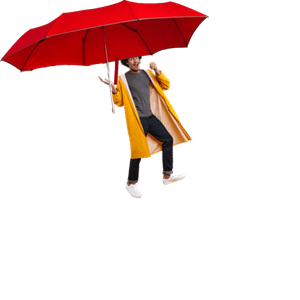

tensor(0.3472)


In [90]:
sigma = 0.1
maxiter = 10
popsize = 64

sel_shapes = []
prev_positios = None

for shape, first_sol in zip(primitives_selected, x0):
    sel_shapes.append(shape)

    es = cma.CMAEvolutionStrategy(first_sol.flatten(), sigma, {
        "maxiter": maxiter,
        "popsize": popsize,
        })

    prev_best = loop(es, sel_shapes, prev_positios)

    if prev_positios is None:
        prev_positios = prev_best.squeeze()
        prev_positios[-1] = 1 / 2
    else:
        prev_positios = np.vstack([prev_positios, prev_best.squeeze()])

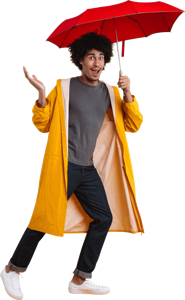

In [124]:
display(SEGMENT_IMGS[prompt_text]['original'])